In [1]:
# Import statements
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from collections import Counter
from datasets import load_dataset
from networkx.algorithms.community import louvain_communities, modularity
import random
from tqdm import tqdm

In [3]:
# Moltbook dataset
df_posts = pd.DataFrame(load_dataset("SimulaMet/moltbook-observatory-archive", "posts")["archive"])
df_comments = pd.DataFrame(load_dataset("SimulaMet/moltbook-observatory-archive", "comments")["archive"])
df_posts    = df_posts.sort_values("fetched_at").drop_duplicates("id", keep="last")
df_comments = df_comments.sort_values("fetched_at").drop_duplicates("id", keep="last")

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/58 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

In [ ]:
# Reddit dataset
ds = load_dataset("anhchanghoangsg/reddit_pushshift_dataset_cleaned", split="train", streaming=True) 
# Streaming as a kwarg here means that it doesn't load the whole thing in SQLite which is nice since the dataset is hundreds of GB.
records = []
# Take top 20000 rows, can change, but dataset is fre aking huge
for row in ds.take(20000):
    records.append({k: row[k] for k in ["author", "parent_id", "subreddit", "name"]})
df_reddit = pd.DataFrame(records).dropna()

Resolving data files:   0%|          | 0/58380 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/58380 [00:00<?, ?it/s]

In [7]:
# #  Moltbook: submolt co-participation ───────────────────────────────────────
post_part    = df_posts[["agent_id","submolt"]].dropna()
comment_part = (df_comments
                .merge(df_posts[["id","submolt"]], left_on="post_id", right_on="id", how="left")
                [["agent_id","submolt"]].dropna())
participation = pd.concat([post_part, comment_part]).drop_duplicates()


G_moltbook = nx.Graph()
for _, grp in participation.groupby("agent_id"):
    for u, v in combinations(grp["submolt"].unique(), 2):
        if G_moltbook.has_edge(u, v): G_moltbook[u][v]["weight"] += 1
        else: G_moltbook.add_edge(u, v, weight=1)

# ── Moltbook: agent reply graph ───────────────────────────────────────────────
parent_map  = df_comments[["id","agent_id"]].rename(columns={"id":"parent_id","agent_id":"parent_agent"})
reply_edges = (df_comments.merge(parent_map, on="parent_id", how="left")
               .dropna(subset=["agent_id","parent_agent"]))
reply_edges = reply_edges[reply_edges["agent_id"] != reply_edges["parent_agent"]]

G_replies = nx.DiGraph()
for (src, tgt), grp in reply_edges.groupby(["agent_id","parent_agent"]):
    G_replies.add_edge(src, tgt, weight=len(grp))

# ── Reddit: user reply graph (t1_ parent = comment reply) ────────────────────
df_reddit["comment_id"]        = df_reddit["name"].str.split("_").str[-1]
df_reddit["parent_comment_id"] = df_reddit["parent_id"].where(
    df_reddit["parent_id"].str.startswith("t1_")
).str.split("_").str[-1]

id2author = df_reddit.set_index("comment_id")["author"].to_dict()
reddit_edges = (df_reddit.dropna(subset=["parent_comment_id"])
                .assign(parent_author=lambda d: d["parent_comment_id"].map(id2author))
                .dropna(subset=["parent_author"]))
reddit_edges = reddit_edges[reddit_edges["author"] != reddit_edges["parent_author"]]

G_reddit = nx.DiGraph()
for (src, tgt), grp in reddit_edges.groupby(["author","parent_author"]):
    G_reddit.add_edge(src, tgt, weight=len(grp))

print(f"Moltbook coparticipation: {G_moltbook.number_of_nodes()} nodes, {G_moltbook.number_of_edges()} edges")
print(f"Moltbook replies:         {G_replies.number_of_nodes()} nodes, {G_replies.number_of_edges()} edges")
print(f"Reddit replies:           {G_reddit.number_of_nodes()} nodes, {G_reddit.number_of_edges()} edges")

Moltbook coparticipation: 3113 nodes, 115249 edges
Moltbook replies:         2797 nodes, 6147 edges
Reddit replies:           1832 nodes, 7753 edges



── Moltbook in-degree (n=1861, mean=3.30) ──
  Power law   alpha=1.796  LL=-2308.5  AIC=4619.1
  Exponential lam=0.303      LL=-4084.6  AIC=8171.2
  Log-normal  mu=0.564 s=0.849  LL=-3385.6  AIC=6775.2
  >> Best fit: power law

── Moltbook out-degree (n=1242, mean=4.95) ──
  Power law   alpha=1.670  LL=-2154.6  AIC=4311.3
  Exponential lam=0.202      LL=-3228.3  AIC=6458.5
  Log-normal  mu=0.799 s=0.960  LL=-2704.4  AIC=5412.9
  >> Best fit: power law

── Reddit in-degree (n=1494, mean=5.19) ──
  Power law   alpha=1.583  LL=-3223.4  AIC=6448.7
  Exponential lam=0.193      LL=-3954.1  AIC=7910.1
  Log-normal  mu=1.022 s=0.997  LL=-3642.7  AIC=7289.5
  >> Best fit: power law

── Reddit out-degree (n=1559, mean=4.97) ──
  Power law   alpha=1.615  LL=-3104.4  AIC=6210.7
  Exponential lam=0.201      LL=-4059.7  AIC=8121.4
  Log-normal  mu=0.932 s=1.016  LL=-3689.9  AIC=7383.7
  >> Best fit: power law


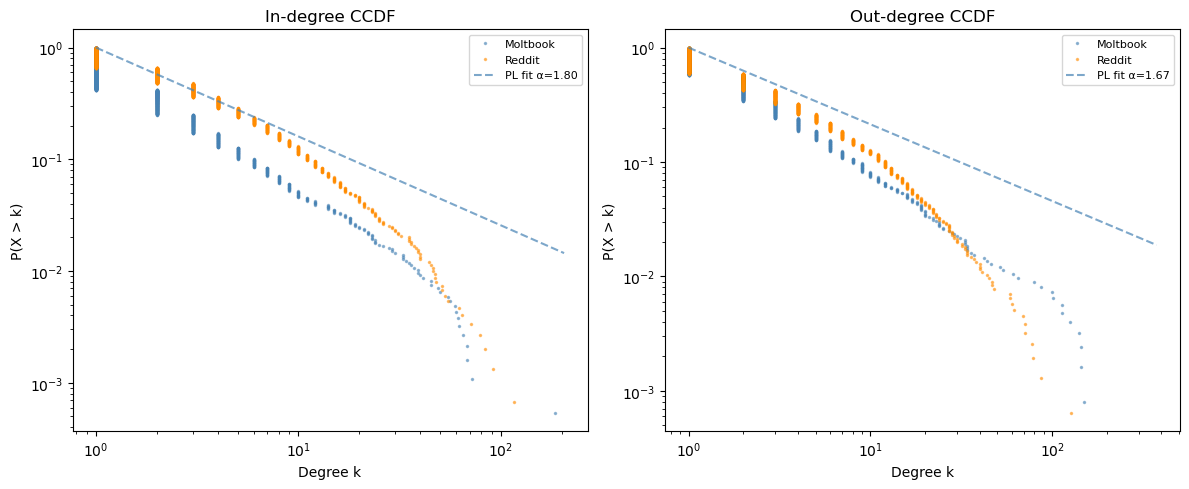

In [8]:
# CELL: Degree distribution analysis + MLE fitting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar, minimize

# ── Extract degree sequences ──────────────────────────────────────────────────
mb_in    = np.array([d for _, d in G_replies.in_degree()  if d > 0])
mb_out   = np.array([d for _, d in G_replies.out_degree() if d > 0])
rd_in    = np.array([d for _, d in G_reddit.in_degree()   if d > 0])
rd_out   = np.array([d for _, d in G_reddit.out_degree()  if d > 0])

# ── MLE for power law: p(k) ~ k^-alpha, k >= k_min ───────────────────────────
def fit_powerlaw(data, k_min=1):
    x = data[data >= k_min].astype(float)
    n = len(x)
    # MLE for discrete power law (Clauset et al. 2009)
    alpha = 1 + n / np.sum(np.log(x / (k_min - 0.5)))
    return alpha, n

# ── MLE for exponential: p(k) ~ exp(-lambda * k) ─────────────────────────────
def fit_exponential(data):
    lam = 1.0 / np.mean(data)
    return lam

# ── MLE for log-normal: fit mu and sigma to log(data) ────────────────────────
def fit_lognormal(data):
    log_x = np.log(data.astype(float))
    return log_x.mean(), log_x.std()

# ── Log-likelihood for each distribution ─────────────────────────────────────
def ll_powerlaw(data, alpha, k_min=1):
    x = data[data >= k_min].astype(float)
    return np.sum(np.log(alpha - 1) - np.log(k_min) - alpha * np.log(x / k_min))

def ll_exponential(data, lam):
    return np.sum(stats.expon.logpdf(data, scale=1/lam))

def ll_lognormal(data, mu, sigma):
    return np.sum(stats.lognorm.logpdf(data, s=sigma, scale=np.exp(mu)))

# ── Fit and compare ───────────────────────────────────────────────────────────
def analyse(data, label):
    alpha, n_pl   = fit_powerlaw(data)
    lam           = fit_exponential(data)
    mu, sigma     = fit_lognormal(data)

    ll_pl  = ll_powerlaw(data, alpha)
    ll_exp = ll_exponential(data, lam)
    ll_ln  = ll_lognormal(data, mu, sigma)

    # AIC = 2k - 2*LL (lower is better); k = number of params
    aic_pl  = 2*1 - 2*ll_pl
    aic_exp = 2*1 - 2*ll_exp
    aic_ln  = 2*2 - 2*ll_ln

    best = min([("power law", aic_pl), ("exponential", aic_exp), ("log-normal", aic_ln)],
               key=lambda x: x[1])

    print(f"\n── {label} (n={len(data)}, mean={data.mean():.2f}) ──")
    print(f"  Power law   alpha={alpha:.3f}  LL={ll_pl:.1f}  AIC={aic_pl:.1f}")
    print(f"  Exponential lam={lam:.3f}      LL={ll_exp:.1f}  AIC={aic_exp:.1f}")
    print(f"  Log-normal  mu={mu:.3f} s={sigma:.3f}  LL={ll_ln:.1f}  AIC={aic_ln:.1f}")
    print(f"  >> Best fit: {best[0]}")
    return alpha, lam, mu, sigma

mb_in_params  = analyse(mb_in,  "Moltbook in-degree")
mb_out_params = analyse(mb_out, "Moltbook out-degree")
rd_in_params  = analyse(rd_in,  "Reddit in-degree")
rd_out_params = analyse(rd_out, "Reddit out-degree")

# ── Plot CCDF (complementary CDF) on log-log ─────────────────────────────────
def plot_ccdf(ax, data, label, color):
    sorted_d = np.sort(data)
    ccdf = 1 - np.arange(1, len(sorted_d)+1) / len(sorted_d)
    ax.loglog(sorted_d, ccdf, '.', alpha=0.5, markersize=3, color=color, label=label)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (mb, rd, title) in zip(axes, [
    (mb_in,  rd_in,  "In-degree CCDF"),
    (mb_out, rd_out, "Out-degree CCDF"),
]):
    plot_ccdf(ax, mb, "Moltbook", "steelblue")
    plot_ccdf(ax, rd, "Reddit",   "darkorange")

    # Overlay power law fit for Moltbook
    alpha_mb = mb_in_params[0] if "In" in title else mb_out_params[0]
    k = np.linspace(1, mb.max(), 200)
    # CCDF of power law ~ k^-(alpha-1)
    pl_ccdf = (k / 1) ** -(alpha_mb - 1)
    pl_ccdf /= pl_ccdf[0]  # normalise to start at 1
    ax.loglog(k, pl_ccdf, '--', color="steelblue", alpha=0.7,
              label=f"PL fit α={alpha_mb:.2f}")

    ax.set_xlabel("Degree k"); ax.set_ylabel("P(X > k)")
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()